In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"D:\SecurePay-AI\dataset\feature_engineered\feature_engineered.csv")

df.head()

,step,type,amount,nameorig,oldbalanceorg,newbalanceorig,namedest,oldbalancedest,newbalancedest,isfraud,isflaggedfraud,amount_category,large_transaction,sender_transaction_count,sender_transaction_amount,receiver_transaction_count,receiver_total_amount,receiver_fraud_count,receiver_fraud_rate,sender_balance_change,receiver_balance_change,balance_ratio,day,hour,night_transaction,receiver_risk_score,receiver_risk_level
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,Low,0,1,9839.64,1,9839.64,0.0,0.000000,9839.64,0.0,0.057834,0,1,1,0.177542,Very Low
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,Low,0,1,1864.28,1,1864.28,0.0,0.000000,1864.28,0.0,0.087731,0,1,1,0.177095,Very Low
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,Very Low,0,1,181.00,44,9922784.61,1.0,0.022727,181.00,0.0,0.994505,0,1,1,9.706460,Very Low
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,Very Low,0,1,181.00,41,18017212.53,1.0,0.024390,181.00,-21182.0,0.994505,0,1,1,9.728175,Very Low
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,Medium,0,1,11668.14,1,11668.14,0.0,0.000000,11668.14,0.0,0.280788,0,1,1,0.177644,Very Low


In [4]:
sender_amount = (
    df.groupby("nameorig")["amount"]
      .sum()
)

df["sender_total_amount"] = (
    df["nameorig"].map(sender_amount)
)

In [5]:
# feature selections

features = [
    "type",
    "amount",
    "oldbalanceorg",
    "newbalanceorig",
    "oldbalancedest",
    "newbalancedest",
    "large_transaction",
    "sender_transaction_count",
    "sender_total_amount",
    "receiver_transaction_count",
    "receiver_total_amount",
    "receiver_fraud_count",
    "receiver_fraud_rate",
    "sender_balance_change",
    "receiver_balance_change",
    "balance_ratio",
    "hour",
    "night_transaction",
    "receiver_risk_score"
]

X = df[features]

y = df["isfraud"]

In [6]:
print(df.columns.tolist())

['step', 'type', 'amount', 'nameorig', 'oldbalanceorg', 'newbalanceorig', 'namedest', 'oldbalancedest', 'newbalancedest', 'isfraud', 'isflaggedfraud', 'amount_category', 'large_transaction', 'sender_transaction_count', 'sender_transaction_amount', 'receiver_transaction_count', 'receiver_total_amount', 'receiver_fraud_count', 'receiver_fraud_rate', 'sender_balance_change', 'receiver_balance_change', 'balance_ratio', 'day', 'hour', 'night_transaction', 'receiver_risk_score', 'receiver_risk_level', 'sender_total_amount']


In [7]:
# encode categorical columns 

from sklearn.preprocessing import LabelEncoder
import joblib

encoder = LabelEncoder()

X["type"] = encoder.fit_transform(X["type"])

C:\Users\sai\AppData\Local\Temp\ipykernel_4836\1614889407.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["type"] = encoder.fit_transform(X["type"])


In [8]:
joblib.dump(encoder, r"D:\SecurePay-AI\ml\lable_encoder.pkl")

['D:\\SecurePay-AI\\ml\\lable_encoder.pkl']

In [9]:
# train test split 

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
# handele class imbalance 
class_weight = "balanced"

In [11]:
# train random forest 

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [12]:
# prediction 

pred = rf.predict(X_test)

In [15]:
# evaluation 

from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("accuracy :",accuracy_score(y_test,pred))
print("pricision :",precision_score(y_test,pred))
print("recall :",recall_score(y_test,pred))
print("f1 score :",f1_score(y_test,pred))

print(classification_report(y_test,pred))

accuracy : 0.9999960708010223
pricision : 1.0
recall : 0.996956786366403
f1 score : 0.9984760743675709
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       1.00      1.00      1.00      1643

    accuracy                           1.00   1272524
   macro avg       1.00      1.00      1.00   1272524
weighted avg       1.00      1.00      1.00   1272524



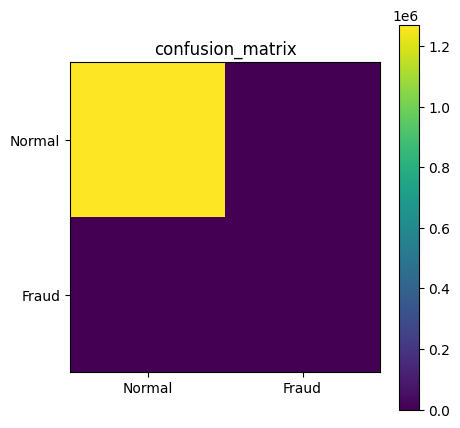

In [16]:
# confusion matrix 

import matplotlib.pyplot as plt

cm = confusion_matrix(y_test,pred)

plt.figure(figsize=(5,5))

plt.imshow(cm)

plt.xticks([0,1],["Normal","Fraud"])
plt.yticks([0,1],["Normal","Fraud"])

plt.colorbar()

plt.title("confusion_matrix")

plt.show()

In [18]:
# feature importance 

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

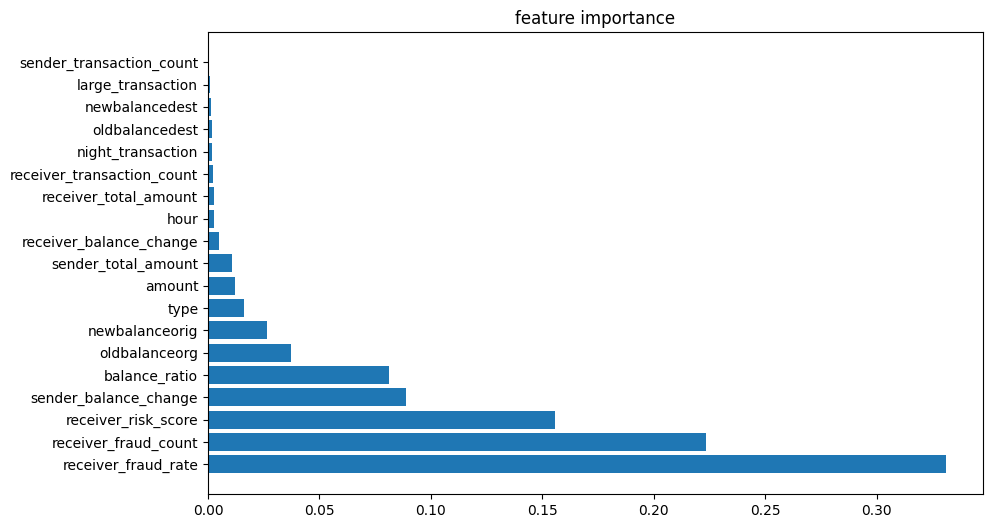

In [19]:
plt.figure(figsize=(10,6))

plt.barh(
    importance.index,
    importance.values
)

plt.title("feature importance")
plt.show()

In [20]:
import joblib
joblib.dump(
    rf,
    r"D:\SecurePay-AI\ml\models\fraud_model.pkl"
)

['D:\\SecurePay-AI\\ml\\models\\fraud_model.pkl']

In [21]:
joblib.dump(
    list(X.columns),
    r"D:\SecurePay-AI\ml\models\feature_columns.pkl"
)

['D:\\SecurePay-AI\\ml\\models\\feature_columns.pkl']

In [22]:
# prediction function 

def predict_transaction(transaction_df):
    model = joblib.load(r"D:\SecurePay-AI\ml\models\fraud_model.pkl")
    return model.predict(transaction_df)